In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from collections import Counter
from tqdm import tqdm

DATASET_ROOT    = "/kaggle/input/datasets/adityarao061/inshopretreival/Dataset/Dataset"   # adjust to your dataset slug
IMG_DIR         = os.path.join(DATASET_ROOT, "Img/img")
PARTITION_FILE  = os.path.join(DATASET_ROOT, "Eval/list_eval_partition.txt")
BBOX_FILE       = None

print("Dataset root exists:", os.path.exists(DATASET_ROOT))

Dataset root exists: True


In [9]:
def parse_partition(filepath):
    with open(filepath, 'r') as f:
        total = int(f.readline().strip())
        _ = f.readline()  # header line
        rows = []
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 3:
                img_path, item_id, split = parts[0], parts[1], parts[2]
                rows.append({'image_path': img_path,
                             'item_id': item_id,
                             'split': split})
    return pd.DataFrame(rows)

df = parse_partition(PARTITION_FILE)
df['full_path'] = df['image_path'].apply(lambda p: os.path.join(DATASET_ROOT, "Img", p))

print(f"Total images : {len(df):,}")
print(df['split'].value_counts())
df.head()

Total images : 52,712
split
train      25882
query      14218
gallery    12612
Name: count, dtype: int64


,image_path,item_id,split,full_path
0,img/WOMEN/Dresses/id_00000002/02_1_front.jpg,id_00000002,train,/kaggle/input/datasets/adityarao061/inshopretr...
1,img/WOMEN/Dresses/id_00000002/02_2_side.jpg,id_00000002,train,/kaggle/input/datasets/adityarao061/inshopretr...
2,img/WOMEN/Dresses/id_00000002/02_4_full.jpg,id_00000002,train,/kaggle/input/datasets/adityarao061/inshopretr...
3,img/WOMEN/Dresses/id_00000002/02_7_additional.jpg,id_00000002,train,/kaggle/input/datasets/adityarao061/inshopretr...
4,img/WOMEN/Skirts/id_00000003/02_1_front.jpg,id_00000003,train,/kaggle/input/datasets/adityarao061/inshopretr...


In [10]:
train_df   = df[df['split'] == 'train'].reset_index(drop=True)
query_df   = df[df['split'] == 'query'].reset_index(drop=True)
gallery_df = df[df['split'] == 'gallery'].reset_index(drop=True)

print(f"Train   : {len(train_df):,} images | {train_df['item_id'].nunique():,} unique items")
print(f"Query   : {len(query_df):,} images | {query_df['item_id'].nunique():,} unique items")
print(f"Gallery : {len(gallery_df):,} images | {gallery_df['item_id'].nunique():,} unique items")

os.makedirs('data', exist_ok=True)
train_df.to_csv('data/train.csv', index=False)
query_df.to_csv('data/query.csv', index=False)
gallery_df.to_csv('data/gallery.csv', index=False)
print("\nSplit CSVs saved to data/")

Train   : 25,882 images | 3,997 unique items
Query   : 14,218 images | 3,985 unique items
Gallery : 12,612 images | 3,985 unique items

Split CSVs saved to data/


In [11]:
# def parse_bbox(filepath):
#     with open(filepath, 'r') as f:
#         total = int(f.readline().strip())
#         _ = f.readline()  # header
#         rows = []
#         for line in f:
#             parts = line.strip().split()
#             if len(parts) >= 5:
#                 rows.append({
#                     'image_path': parts[0],
#                     'x1': int(parts[1]), 'y1': int(parts[2]),
#                     'x2': int(parts[3]), 'y2': int(parts[4])
#                 })
    
#     return pd.DataFrame(rows)

# bbox_df = parse_bbox(BBOX_FILE)
# # Merge into main dataframe
# df = df.merge(bbox_df, on='image_path', how='left')
# print("BBox missing rate:", df[['x1','y1','x2','y2']].isna().mean().mean())
# df.head()

# No bbox file available, add placeholder columns
df['x1'] = np.nan
df['y1'] = np.nan
df['x2'] = np.nan
df['y2'] = np.nan
print("BBox file not found — skipping, columns set to NaN")
   

BBox file not found — skipping, columns set to NaN


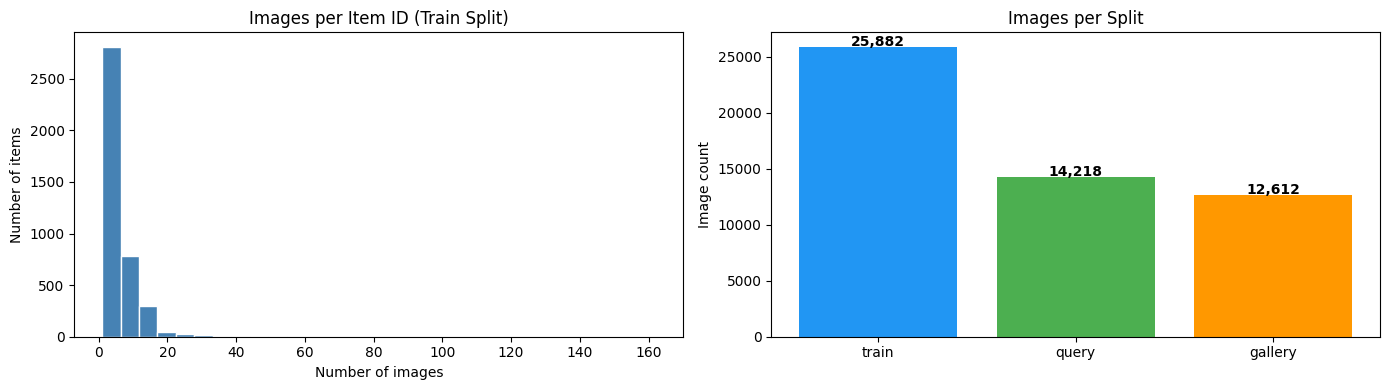

Mean images/item: 6.48
Min/Max         : 1 / 162


In [12]:
imgs_per_item = train_df.groupby('item_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(imgs_per_item, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Images per Item ID (Train Split)')
axes[0].set_xlabel('Number of images')
axes[0].set_ylabel('Number of items')

split_counts = df['split'].value_counts()
axes[1].bar(split_counts.index, split_counts.values,
            color=['#2196F3','#4CAF50','#FF9800'])
axes[1].set_title('Images per Split')
axes[1].set_ylabel('Image count')
for i, v in enumerate(split_counts.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Mean images/item: {imgs_per_item.mean():.2f}")
print(f"Min/Max         : {imgs_per_item.min()} / {imgs_per_item.max()}")

In [13]:
# def show_item_samples(df, n_items=4, imgs_per_item=3):
#     items = df['item_id'].drop_duplicates().sample(n_items, random_state=42).tolist()
#     fig, axes = plt.subplots(n_items, imgs_per_item,
#                              figsize=(imgs_per_item * 3, n_items * 4))
#     for row, item in enumerate(items):
#         subset = df[df['item_id'] == item].sample(
#             min(imgs_per_item, len(df[df['item_id'] == item])),
#             random_state=0)
#         for col, (_, r) in enumerate(subset.iterrows()):
#             ax = axes[row][col]
#             try:
#                 img = Image.open(r['full_path']).convert('RGB')
#                 ax.imshow(img)
#             except Exception:
#                 ax.text(0.5, 0.5, 'Image\nnot found',
#                         ha='center', va='center', transform=ax.transAxes)
#             ax.set_title(item[-8:], fontsize=8)
#             ax.axis('off')
#         # blank remaining cols
#         for col in range(len(subset), imgs_per_item):
#             axes[row][col].axis('off')
#     plt.suptitle('Sample Items from Train Split', fontsize=13, fontweight='bold')
#     plt.tight_layout()
#     plt.show()

# show_item_samples(train_df, n_items=4, imgs_per_item=3)

In [14]:
# sample_paths = train_df['full_path'].sample(500, random_state=0).tolist()
# widths, heights = [], []
# for p in tqdm(sample_paths, desc='Reading image sizes'):
#     try:
#         w, h = Image.open(p).size
#         widths.append(w); heights.append(h)
#     except Exception:
#         pass

# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# axes[0].hist(widths,  bins=30, color='coral',     edgecolor='white')
# axes[0].set_title('Image Width Distribution (sample)')
# axes[1].hist(heights, bins=30, color='mediumseagreen', edgecolor='white')
# axes[1].set_title('Image Height Distribution (sample)')
# plt.tight_layout()
# plt.show()
# print(f"Width  — mean: {np.mean(widths):.0f}, median: {np.median(widths):.0f}")
# print(f"Height — mean: {np.mean(heights):.0f}, median: {np.median(heights):.0f}")